In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import shap

"""
Column names and type information:

age: continuous.
workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
fnlwgt: continuous.
education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
education-num: continuous.
marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
sex: Female, Male.
capital-gain: continuous.
capital-loss: continuous.
hours-per-week: continuous.
native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

Columns absent from dataset
"""
# --- Load dataset ---
df = pd.read_csv("data/raw/adult.data", header=None, names=[
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"])


# --- Simple preprocessing ---
df = df.dropna()
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
#df = pd.get_dummies(df, drop_first=True)

feature_cols = ['age', 'workclass', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
feature_cols = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country"]

y = (df["income"].astype(str) == ">50K").astype(int)



In [30]:

X = df[feature_cols]
X = pd.get_dummies(X, drop_first=True)
# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# --- Scale for logistic regression ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Models ---
log_model = LogisticRegression(max_iter=1000)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")

# --- Train ---
log_model.fit(X_train_scaled, y_train)
xgb_model.fit(X_train, y_train)

# --- Predict ---
log_pred = log_model.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test)

# --- Evaluate ---
print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

/home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [12:24:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Logistic Accuracy: 0.8572086596038692
XGBoost Accuracy: 0.8739444188545985


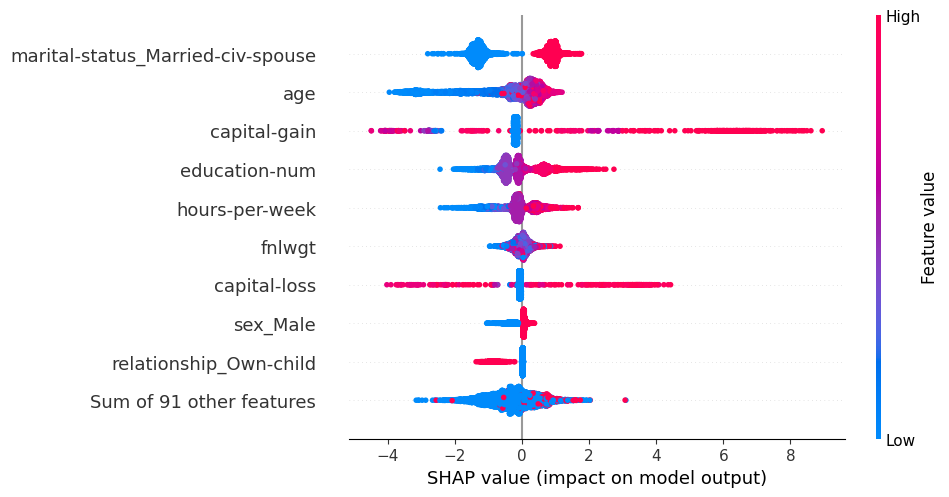

In [31]:
# --- SHAP for XGBoost ---
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

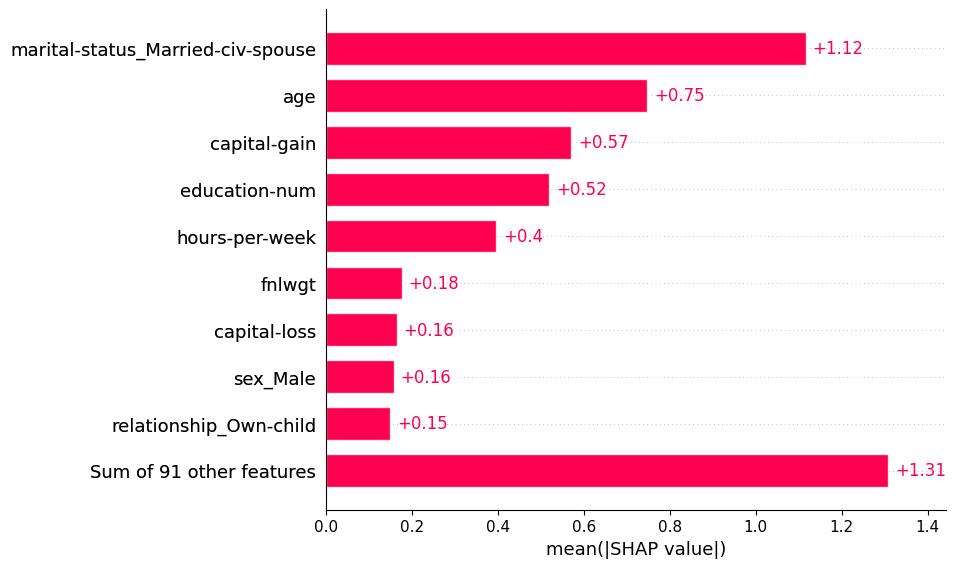

In [33]:
# shap bar plot
shap.plots.bar(shap_values)

In [35]:
# shap dependency plot
